# BITS PILANI — WILP  |  M.Tech AIML
## AIMLCZG546 — Software Engineering for Machine Learning
# Assignment I — Requirements Formulation & System Architecture
### Automated Loan Underwriting (Consumer Credit Risk)

**Group No: 84**

| Sl. No | BITS ID | Name | Qualitative Contribution | % |
|:--:|:--|:--|:--|:--:|
| 1 | 2025AA05710 | Singh Pritesh Sanjay Poonam | Quality-Attribute Testing, Performance Benchmarking, System Integration | 25% |
| 2 | 2025AA05368 | Gangera Tushar Kantibhai Dayaben | Requirements Formulation, Problem Statement, GR4ML Modeling | 25% |
| 3 | 2025AB05154 | Gangam Shuba Nandini | Feature Engineering, ML Pipeline Design, Model Training | 25% |
| 4 | 2025AA05574 | Shaifali Garg | System Architecture, FastAPI Serving, Event Simulation | 25% |

---

## Objective 1 — Requirements Formulation  *(5 Marks)*

### 1. Domain & Problem Statement
**Domain:** Consumer Credit Risk Assessment & Automated Loan Underwriting.

**Problem Statement:** Traditional manual underwriting of consumer credit is slow, labour-intensive and
susceptible to cognitive bias. This project implements a real-time, Machine-Learning-based decision-support
service that automates loan underwriting. The service consumes applicant demographics, credit metrics and
asset–liability levels and classifies each application as **Approved** or **Denied**, along with a risk tier
(LOW / MEDIUM / HIGH). To protect the downstream estimator and guarantee a premium user experience, the
system enforces a strict Pydantic data-validation boundary (100% of malformed payloads rejected) and keeps
average inference latency well under a 150 ms SLA.

### 2. GR4ML Requirement Specifications & Goals
GR4ML organises requirements across three integrated views.

**I. Business View**

| Element | Description / Content |
|:--|:--|
| Actors | Loan Applicant (submits financial details), Credit Officer (reviews flagged applications) |
| Strategic Goals | Minimise loan defaults (risk control); automate application flow (operational efficiency) |
| Decision Goal | Approve / Deny / Flag the loan application |
| Question Goal | Is the applicant's credit risk within acceptable limits? |
| Indicators | Default rate < 2.5%; auto-approval rate > 80%; response latency < 150 ms |
| Insights | Default-probability score; risk tier (LOW/MED/HIGH); computed net worth |

**II. Analytics Design & III. Data Preparation Views**

| Element | Description / Content |
|:--|:--|
| Analytics Goal | Prediction — binary classification of default risk |
| Candidate Algorithms | **Random Forest** (chosen) vs **Logistic Regression** (explainable baseline) |
| Softgoals | Accuracy, Performance (latency), Explainability (feature importance), Reliability (Pydantic) |
| Raw Entities | Loan applications (demographics), credit-bureau history, asset registry |
| Prep Tasks | Drop non-predictive/redundant/low-importance cols, categorical encoding, feature engineering |
| Operators | Correlation filter, importance filter, `LabelEncoder`, ratio engineering, Pydantic validators |

### 3. GR4ML Graphical Notations

**GR4ML Business View**

![Business View](diagrams/gr4ml_business_view.png)

**GR4ML Analytics Design View** — two candidate algorithms scored against the quality softgoals; Random
Forest wins the dominant *Accuracy* softgoal and is selected for serving.

![Analytics Design View](diagrams/gr4ml_analytics_design_view.png)

**GR4ML Data Preparation View** — the five-stage feature-engineering pipeline and the data-quality goal each
stage operationalises.

![Data Preparation View](diagrams/gr4ml_data_prep_view.png)

### 4. Top Three Quality Requirements

1. **Robustness (Pydantic boundary validation).** ML estimators cannot natively handle out-of-range or
   corrupted inputs. A strict validation filter (credit score ∈ [300, 850], age ≥ 18, loan ≤ 500% of income)
   stops bad inputs from causing silent failures inside the model.
   *Metric:* 100% of invalid inputs rejected at the API boundary (HTTP 422/400).

2. **Reliability (type-safe, well-formed outputs).** Every response conforms to the `LoanApprovalResult`
   JSON schema, enabling seamless integration with downstream ledgers.
   *Metric:* zero unhandled 500 responses; deterministic risk-tier mapping.

3. **Performance (latency).** Inference must run in real time under concurrent traffic in consumer-loan portals.
   *Metric:* average pipeline latency < 150 ms.

*These three dominate because an underwriting service is a **trust boundary**: it must never crash on hostile
input (robustness), must return contract-conformant decisions (reliability), and must do so fast enough for an
interactive portal (performance). They are the quality attributes most directly verifiable and most costly to
violate in production.*

---

## Objective 2 — System Architecture  *(5 Marks)*

### 5. System Architecture Diagram
The architecture cleanly separates **ML components** (data, training, model artefact), the **FastAPI
inference service** (the Pipe-and-Filter runtime), and **non-ML components** (API clients, config, schemas,
health check, structured logging).

![System Architecture](diagrams/system_architecture.png)

### 6. Selected Architectural Patterns

**Pattern 1 — Pipe-and-Filter.** The prediction process is an ordered sequence of isolated, pure filters
connected by pipes: `validate_input → extract_features → run_model → format_response`. This decouples business
rules, feature math, ML inference and risk classification; each filter is independently testable.

**Pattern 2 — Microservice Serving with Event Logging.** The pipeline is wrapped in a FastAPI REST service
exposing `POST /predict` and `GET /health`. Every transaction emits a structured JSON log line (latency,
credit score, decision, risk tier) suitable for monitoring dashboards.

### 7. Implementation — Executable Verification
The cells below run the **actual repository code** end-to-end: data preparation → algorithm comparison →
Pipe-and-Filter execution → FastAPI serving → quality-attribute test suite.

> **Reproducibility note.** The licensed Kaggle *Financial Risk for Loan Approval* file is not redistributed.
> If `data/Loan.csv` is absent, the first cell generates a **schema-identical synthetic stand-in** with a
> genuine learnable signal, so every cell runs without the private download.

In [1]:
# 7a. Data preparation  (mirrors data/prepare_data.py)
import os, sys, subprocess
import pandas as pd, numpy as np
from sklearn.preprocessing import LabelEncoder

if not os.path.exists("data/Loan.csv"):
    subprocess.run([sys.executable, "data/generate_synthetic_data.py"], check=True)

df_raw = pd.read_csv("data/Loan.csv")
print("Raw dataset shape:", df_raw.shape)

df = df_raw.drop(columns=['ApplicationDate', 'RiskScore', 'InterestRate',
                          'BaseInterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio'])
df = df.drop(columns=['MonthlyIncome', 'Experience', 'TotalAssets'])              # redundant (r>0.95)
df = df.drop(columns=['MaritalStatus', 'HomeOwnershipStatus', 'NumberOfDependents',
                      'NumberOfCreditInquiries', 'NumberOfOpenCreditLines',
                      'UtilityBillsPaymentHistory'])                              # low importance
for col in ['EmploymentStatus', 'EducationLevel', 'LoanPurpose']:
    df[col] = LabelEncoder().fit_transform(df[col])
df['LoanToIncomeRatio']  = df['LoanAmount'] / (df['AnnualIncome'] + 1)
df['SavingsToLoanRatio'] = df['SavingsAccountBalance'] / (df['LoanAmount'] + 1)

print("Processed shape:", df.shape, "->", df.shape[1]-1, "features + target")
print("Target distribution:\n", df['LoanApproved'].value_counts())
df.head()

Raw dataset shape: (20000, 36)
Processed shape: (20000, 23) -> 22 features + target
Target distribution:
 LoanApproved
0    11936
1     8064
Name: count, dtype: int64


,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,LoanAmount,LoanDuration,MonthlyDebtPayments,CreditCardUtilizationRate,DebtToIncomeRatio,...,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalLiabilities,JobTenure,NetWorth,LoanApproved,LoanToIncomeRatio,SavingsToLoanRatio
0,23,21744,517,0,3,16245,60,591,0.515,0.326,...,2,3,13728,607,8989,4,81521,0,0.747068,0.845008
1,62,44473,535,0,0,7736,120,466,0.199,0.126,...,6,17,11212,5787,4036,23,196239,0,0.173944,1.449140
2,55,22602,710,1,3,11955,48,284,0.380,0.151,...,45,19,17656,1875,19870,22,87425,1,0.528912,1.476748
3,43,150357,653,0,0,198837,48,1380,0.272,0.110,...,46,18,91878,1563,383468,16,46621,1,1.322424,0.462075
4,43,60249,577,0,2,22336,48,1244,0.782,0.248,...,44,23,21398,5828,10341,22,87020,0,0.370722,0.957962


In [2]:
# 7b. Algorithm comparison  (mirrors training/step1_notebook.py)  — Analytics Design View
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import joblib

FEATURES = [c for c in df.columns if c != 'LoanApproved']
X, y = df[FEATURES], df['LoanApproved']
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42)).fit(Xtr, ytr)
rf = RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42).fit(Xtr, ytr)

for name, m in [("Logistic Regression", logreg), ("Random Forest (CHOSEN)", rf)]:
    p = m.predict(Xte)
    print(f"{name:<24} accuracy={accuracy_score(yte,p):.4f}  "
          f"roc_auc={roc_auc_score(yte, m.predict_proba(Xte)[:,1]):.4f}")

print("\nRandom Forest classification report:")
print(classification_report(yte, rf.predict(Xte)))

os.makedirs("app", exist_ok=True)
joblib.dump(rf, "app/model.pkl")
print("Chosen model (Random Forest) serialised -> app/model.pkl")

Logistic Regression      accuracy=0.9030  roc_auc=0.9686
Random Forest (CHOSEN)   accuracy=0.9473  roc_auc=0.9876

Random Forest classification report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96      2387
           1       0.95      0.91      0.93      1613

    accuracy                           0.95      4000
   macro avg       0.95      0.94      0.94      4000
weighted avg       0.95      0.95      0.95      4000

Chosen model (Random Forest) serialised -> app/model.pkl


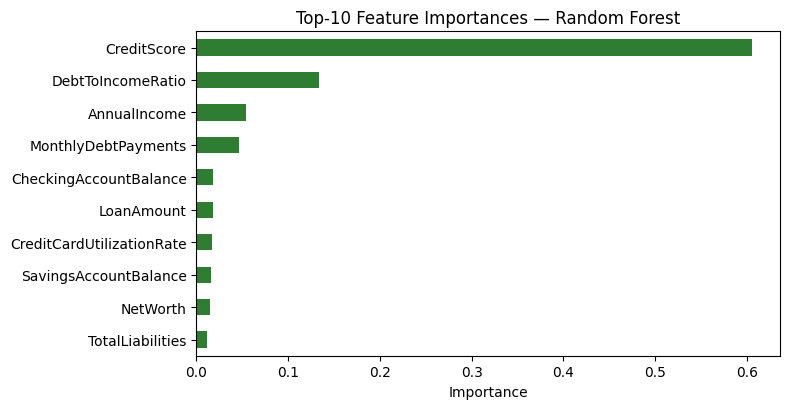

In [3]:
# 7b-ii. Feature importances (drives the Explainability softgoal)
import matplotlib.pyplot as plt
imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False).head(10)
ax = imp[::-1].plot(kind='barh', figsize=(8, 4.2), color='#2E7D32')
ax.set_title('Top-10 Feature Importances — Random Forest'); ax.set_xlabel('Importance')
plt.tight_layout(); plt.show()

In [4]:
# 7c. Pipe-and-Filter execution (app/pipeline.py) — low-risk, high-risk, and a business-rule rejection
from app.schemas import LoanApplicationInput
from app.pipeline import execute_pipeline
clf = joblib.load("app/model.pkl")

low_risk = LoanApplicationInput(age=45, annual_income=95000, credit_score=720, employment_status=0,
    education_level=4, loan_amount=25000, loan_duration=36, monthly_debt_payments=400,
    credit_card_utilization_rate=0.25, debt_to_income_ratio=0.15, bankruptcy_history=0, loan_purpose=3,
    previous_loan_defaults=0, payment_history=28, length_of_credit_history=15,
    savings_account_balance=35000, checking_account_balance=8000, total_liabilities=30000,
    job_tenure=10, net_worth=220000)
high_risk = LoanApplicationInput(age=23, annual_income=28000, credit_score=480, employment_status=2,
    education_level=3, loan_amount=40000, loan_duration=60, monthly_debt_payments=900,
    credit_card_utilization_rate=0.88, debt_to_income_ratio=0.65, bankruptcy_history=1, loan_purpose=4,
    previous_loan_defaults=1, payment_history=12, length_of_credit_history=2,
    savings_account_balance=200, checking_account_balance=500, total_liabilities=45000,
    job_tenure=1, net_worth=-10000)

print("LOW-RISK  ->", execute_pipeline(low_risk, clf).model_dump_json())
print("HIGH-RISK ->", execute_pipeline(high_risk, clf).model_dump_json())

print("\nBusiness-rule rejection (loan > 500% of income):")
try:
    execute_pipeline(LoanApplicationInput(age=28, annual_income=20000, credit_score=600,
        employment_status=1, education_level=1, loan_amount=120000, loan_duration=60,
        monthly_debt_payments=500, credit_card_utilization_rate=0.5, debt_to_income_ratio=0.4,
        bankruptcy_history=0, loan_purpose=3, previous_loan_defaults=0, payment_history=20,
        length_of_credit_history=5, savings_account_balance=2000, checking_account_balance=1000,
        total_liabilities=15000, job_tenure=3, net_worth=10000), clf)
except ValueError as e:
    print("  Caught ->", e)

Configurations loaded successfully from C:\Users\singh\AppData\Local\Temp\claude\C--Users-singh-OneDrive-Documents-AI-Engineer\521ce143-ad78-49e7-a022-659324ae64af\scratchpad\MLModel_FastAPI_Architecture\configs\config.yaml
LOW-RISK  -> {"is_approved":true,"probability":0.9313,"risk_tier":"LOW","net_worth":220000,"debt_to_income":0.15,"latency_ms":4.53}
HIGH-RISK -> {"is_approved":false,"probability":0.0458,"risk_tier":"HIGH","net_worth":-10000,"debt_to_income":0.65,"latency_ms":3.54}

Business-rule rejection (loan > 500% of income):
  Caught -> Requested loan amount exceeds 500% of the applicant's annual income.


In [5]:
# 7d. FastAPI serving verification (fastapi.testclient.TestClient)
from fastapi.testclient import TestClient
from app.main import app
client = TestClient(app)

print("GET /health ->", client.get("/health").json())

valid = low_risk.model_dump()
r = client.post("/predict", json=valid)
print("POST /predict (valid)   ->", r.status_code, r.json())

r_bad = client.post("/predict", json={**valid, "credit_score": 950})
print("POST /predict (invalid) ->", r_bad.status_code, "|", r_bad.json()["detail"][0]["msg"])

Model loaded successfully from C:\Users\singh\AppData\Local\Temp\claude\C--Users-singh-OneDrive-Documents-AI-Engineer\521ce143-ad78-49e7-a022-659324ae64af\scratchpad\MLModel_FastAPI_Architecture\app/model.pkl
GET /health -> {'status': 'healthy', 'model_status': 'loaded', 'environment': 'production', 'features_configured': 22}
{"timestamp": "2026-07-01T23:17:07Z", "level": "INFO", "message": "loan_evaluation_served", "logger": "loan_service", "latency_ms": 4.2, "credit_score": 720, "loan_amount": 25000, "is_approved": true, "probability": 0.9313, "risk_tier": "LOW"}


POST /predict (valid)   -> 200 {'is_approved': True, 'probability': 0.9313, 'risk_tier': 'LOW', 'net_worth': 220000, 'debt_to_income': 0.15, 'latency_ms': 4.18}
POST /predict (invalid) -> 422 | Input should be less than or equal to 850


C:\Users\singh\AppData\Local\Programs\Python\Python313\Lib\site-packages\fastapi\testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
  from starlette.testclient import TestClient as TestClient  # noqa


### 8. Quality-Attribute Test Suite
The seven unit tests in `tests/test_quality_attrs.py` verify the top quality requirements and the
Pipe-and-Filter properties (filter purity/isolation).

In [6]:
# 8. Run the quality-attribute suite
import unittest
from tests import test_quality_attrs
suite = unittest.TestLoader().loadTestsFromModule(test_quality_attrs)
result = unittest.TextTestRunner(verbosity=2).run(suite)
print("\nSUMMARY:", "ALL PASSED" if result.wasSuccessful() else "FAILURES",
      f"({suite.countTestCases()} tests)")

test_feature_extraction_filter_isolation (tests.test_quality_attrs.TestQualityAttributes.test_feature_extraction_filter_isolation)
extract_features must be deterministic and shape-correct in isolation. ... 

ok


test_inference_pipeline_latency (tests.test_quality_attrs.TestQualityAttributes.test_inference_pipeline_latency)
Average pipeline latency must stay under the 150 ms SLA. ... 

ok


test_pipeline_output_conforms_to_schema (tests.test_quality_attrs.TestQualityAttributes.test_pipeline_output_conforms_to_schema)
The full pipeline must return a well-formed LoanApprovalResult. ... 

...

ok


test_validation_filter_is_pure (tests.test_quality_attrs.TestQualityAttributes.test_validation_filter_is_pure)
validate_input must not mutate its input and must be idempotent. ... 

ok


----------------------------------------------------------------------
Ran 7 tests in 0.210s

OK



SUMMARY: ALL PASSED (7 tests)


### Application Demonstration
Live request/response pairs captured from the running service (approved, denied, and a rejected
out-of-range input), plus the interactive Swagger UI.

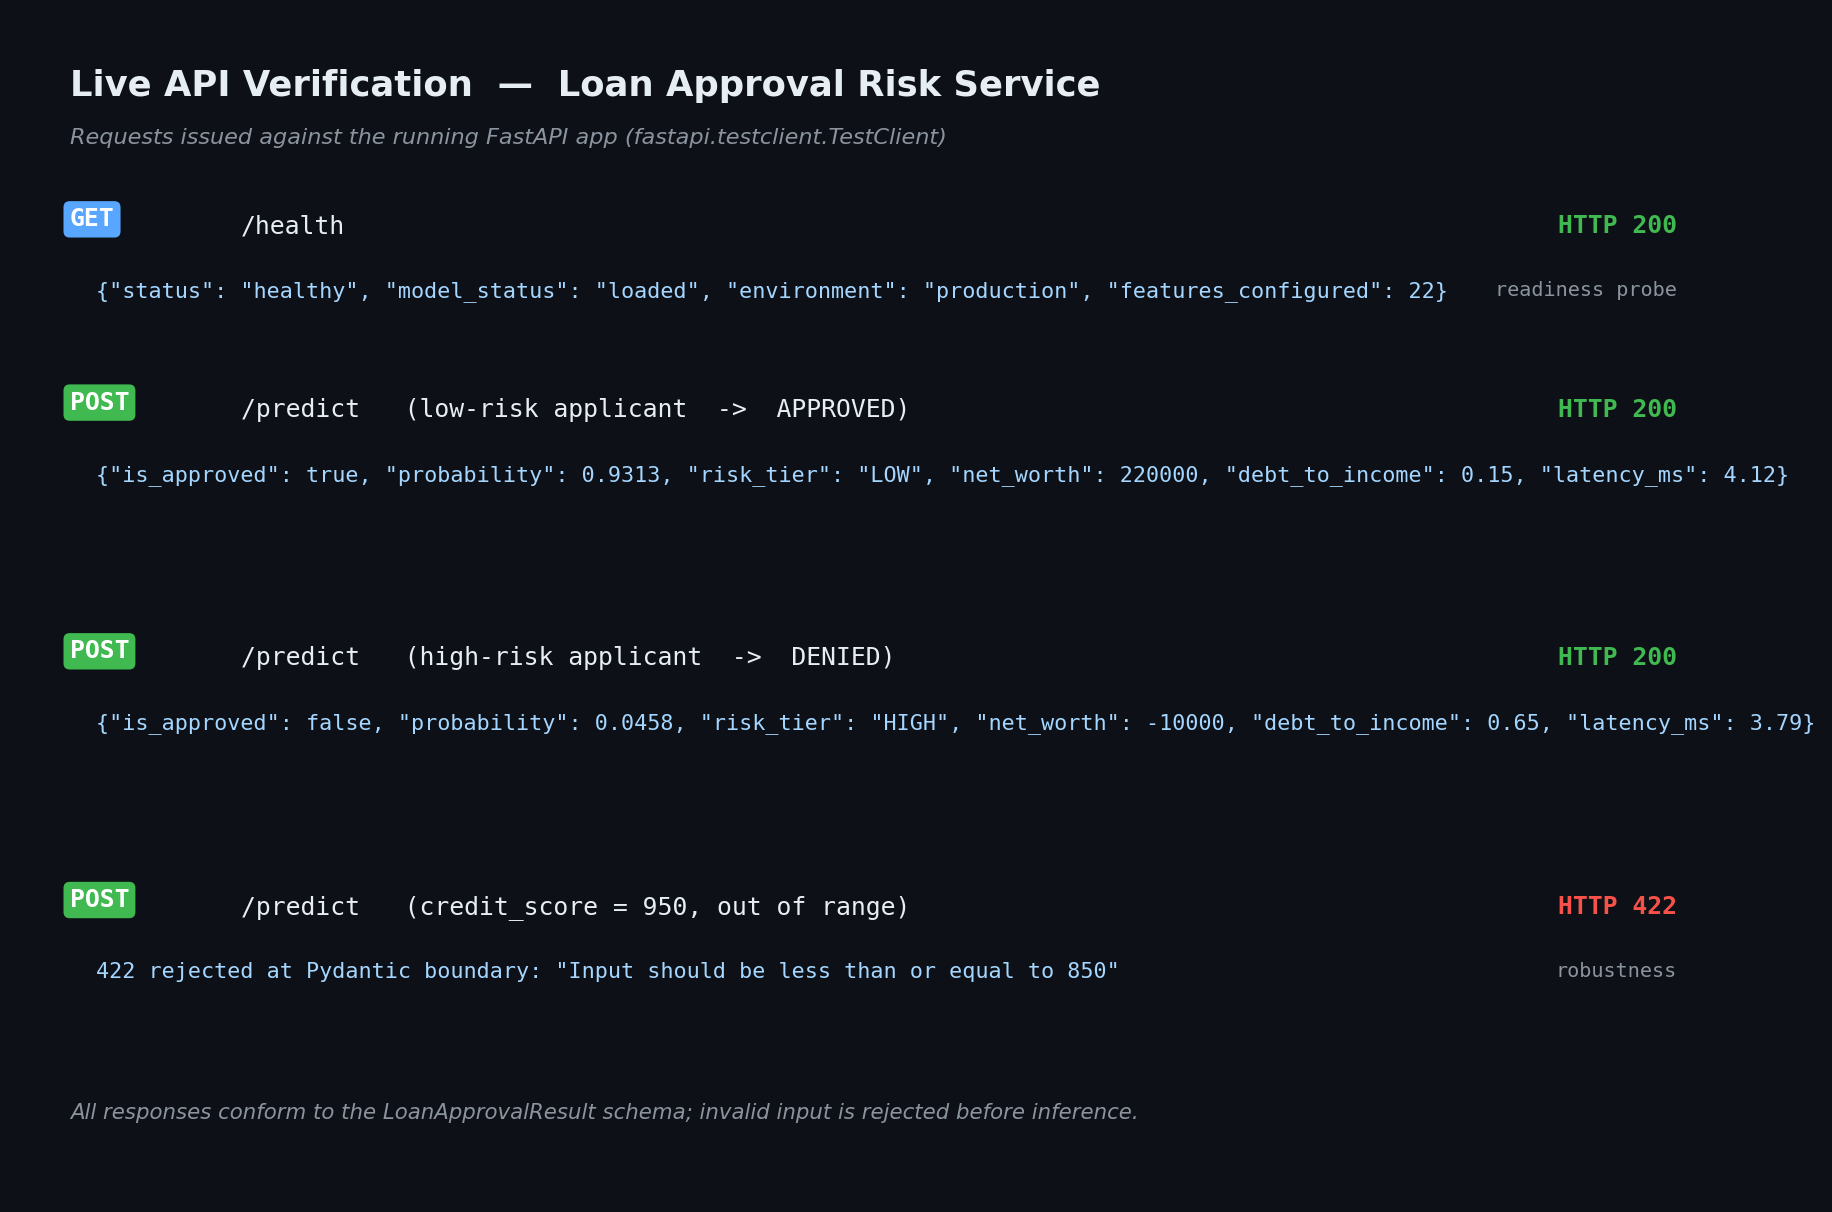

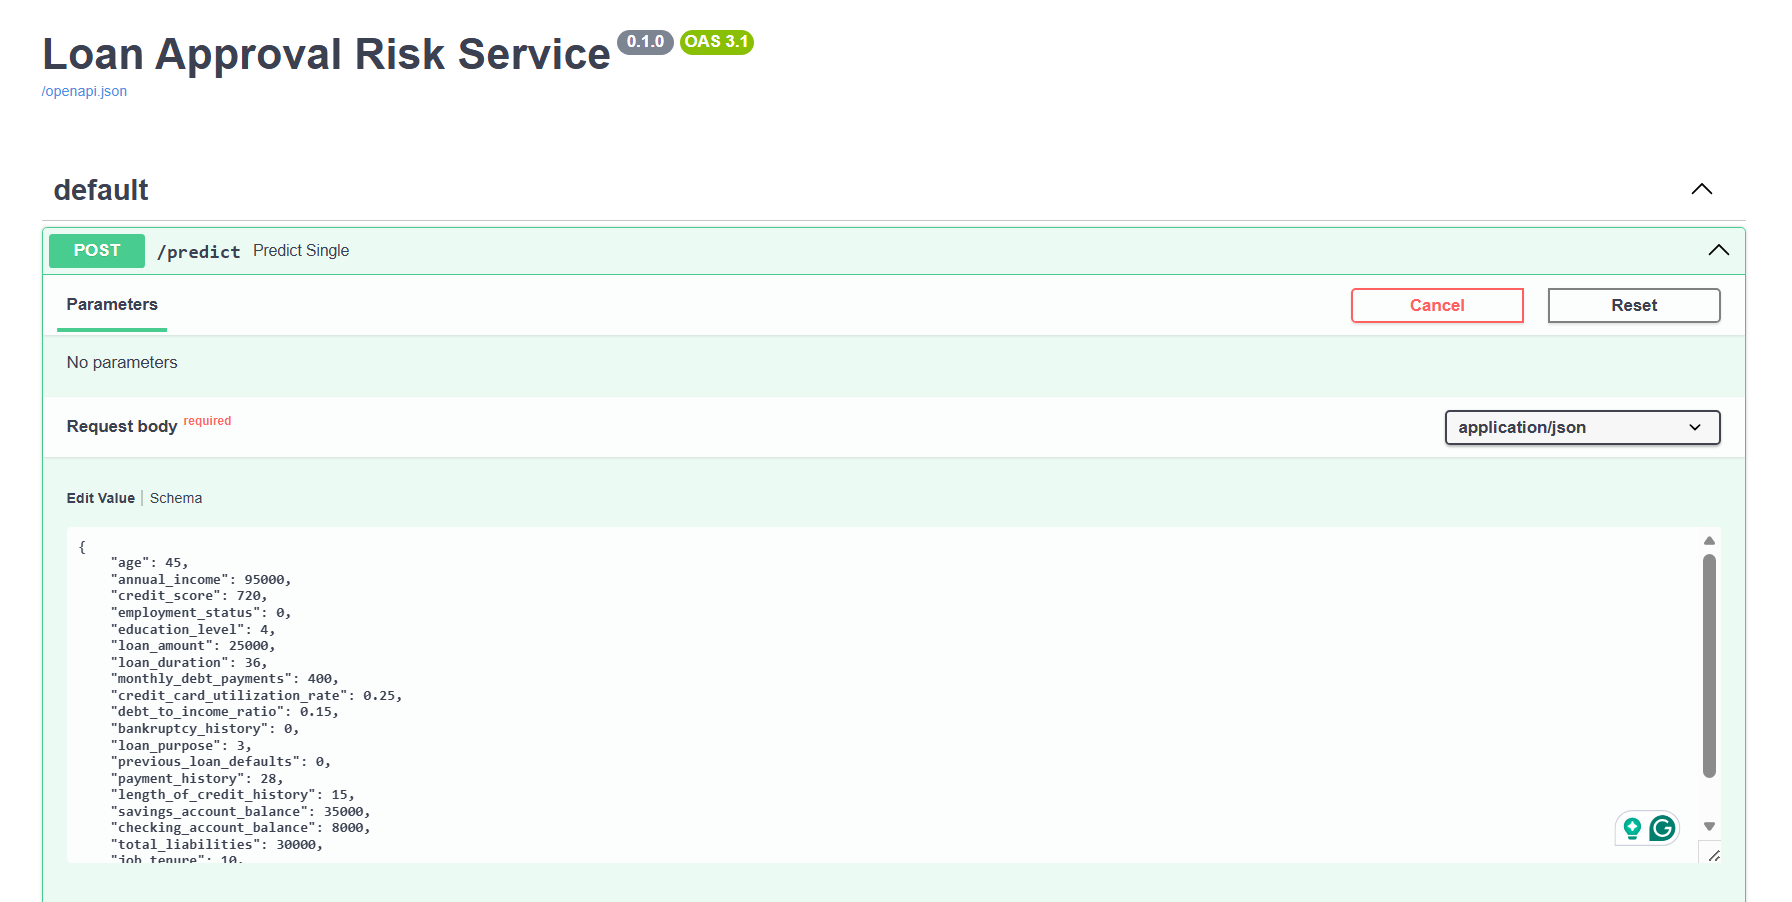

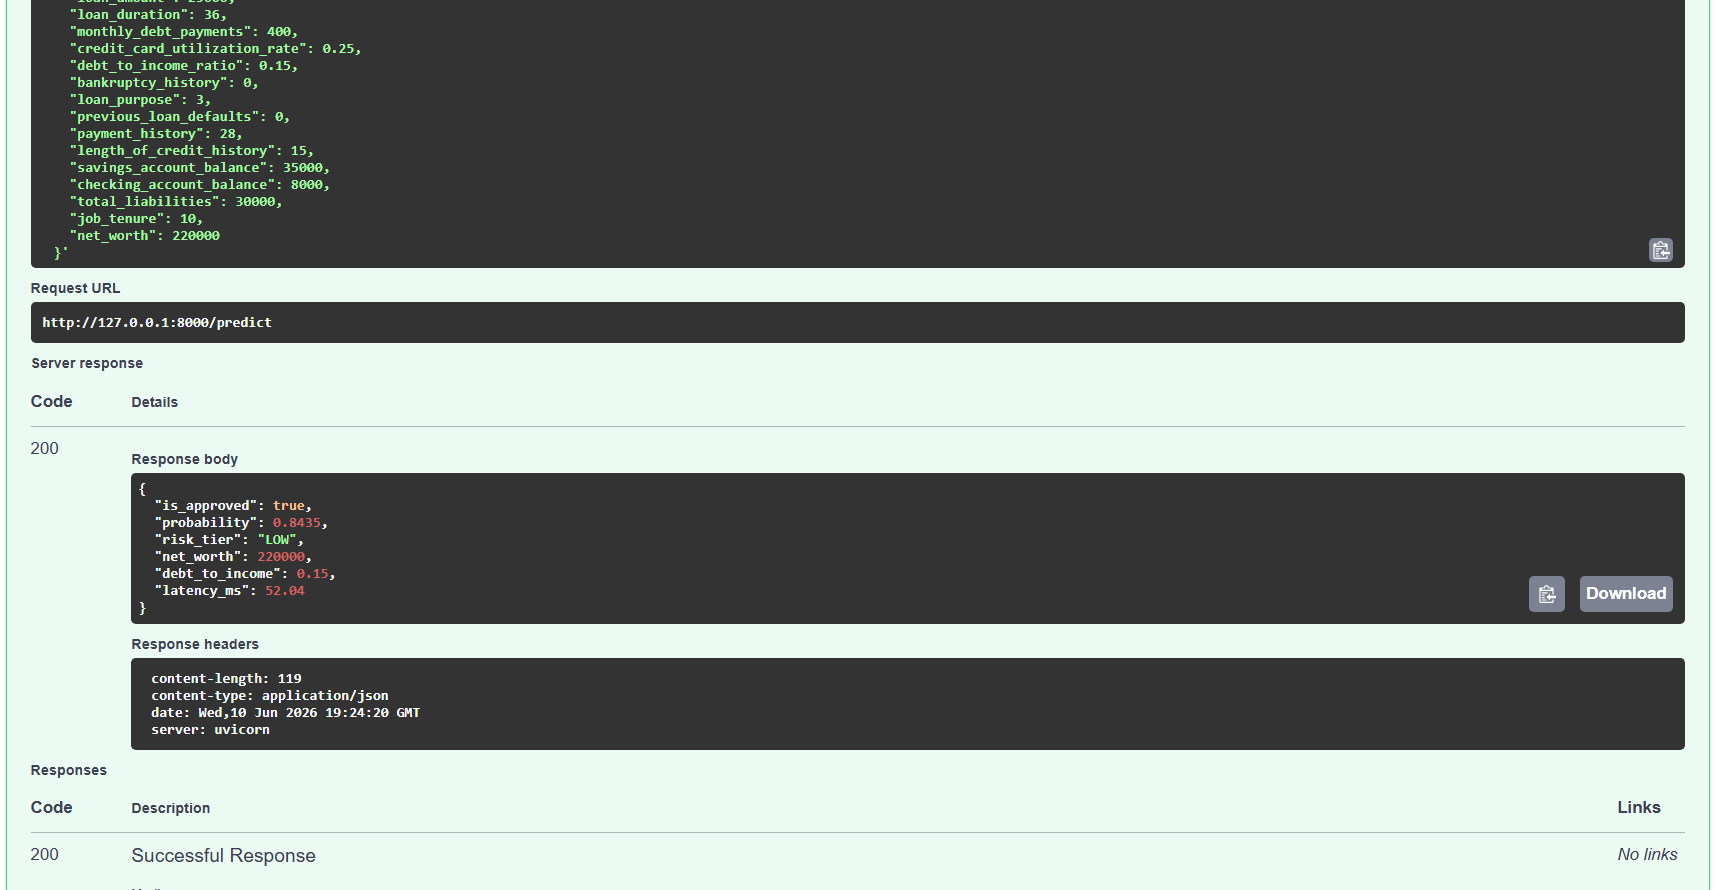

In [7]:
from IPython.display import Image, display
for img in ["diagrams/api_verification.png",
            "diagrams/swagger_request.png",
            "diagrams/swagger_response.png"]:
    display(Image(filename=img))

### Conclusion
Using GR4ML for requirements modelling and two complementary architectural patterns (Pipe-and-Filter +
FastAPI microservice), Group 84 engineered a credit-underwriting service that is **robust** (Pydantic
boundary), **reliable** (schema-conformant, deterministic risk tiers) and **performant** (< 150 ms). The
Analytics Design View trade-off is realised in code — Random Forest (94.7% accuracy) is chosen over the
Logistic Regression baseline (90.3%) on the dominant Accuracy softgoal — and all seven quality-attribute
tests pass, demonstrating that the target quality requirements are met.